Test import

In [101]:
import torch

test transform and show image

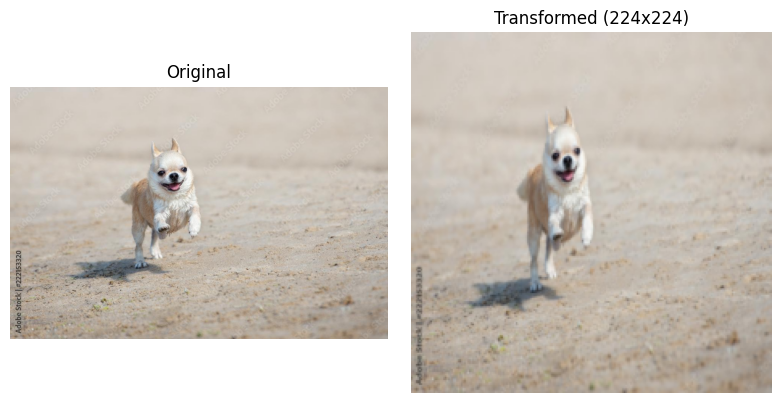

In [116]:
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as transforms
import torch

from pathlib import Path
from typing import cast
from PIL import Image

PATH: Path = Path("./data/test/chihuahua/img_4_568.jpg")

img: Image.Image = Image.open(PATH).convert("RGB")

transform: transforms.Compose = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])

img_tensor: torch.Tensor = cast(torch.Tensor, transform(img))

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(img)
ax1.set_title("Original")
ax1.axis("off")

ax2.imshow(img_tensor.permute(1, 2, 0).numpy())
ax2.set_title("Transformed (224x224)")
ax2.axis("off")

plt.tight_layout()
plt.show()

create datasets train and test

In [103]:
from torchvision import datasets
from torchvision.datasets import ImageFolder

transform: transforms.Compose = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.ToDtype(torch.float32, scale=True),

])

train_dataset: ImageFolder = datasets.ImageFolder(
    root="./data/train",
    transform=transform,
)

test_dataset: ImageFolder = datasets.ImageFolder(
    root="./data/test",
    transform=transform,
)

class_to_idx: dict[str, int] = train_dataset.class_to_idx
print(class_to_idx)

{'chihuahua': 0, 'muffin': 1}


load batch of dataset

In [104]:
from torch.utils.data import DataLoader

train_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]] = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]] = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

images: torch.Tensor
labels: torch.Tensor
images, labels = next(iter(train_loader))

print(images.shape)  # (32, 3, 224, 224)
print(labels.shape)  # (32,)
print(labels)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 1, 1])


Create model structure

In [105]:
import torch.nn as nn
import torch

class SnifferCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

print model structure

In [106]:
device: torch.device = torch.device("cpu")
model: SnifferCNN = SnifferCNN().to(device)
print(model)

SnifferCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


optimizer la loss. Learning rate élevé -> steps d'apprentissage trop larges. Si trop bas, très lent

In [107]:
import torch.optim as optim

loss_function: nn.CrossEntropyLoss = nn.CrossEntropyLoss()
optimizer: optim.Adam = optim.Adam(
    model.parameters(),
    lr=0.001,
)

Training    

In [108]:
epochs: int = 5

epoch: int
for epoch in range(epochs):
    model.train()
    total_loss: float = 0.0

    batch_images: torch.Tensor
    batch_labels: torch.Tensor
    for batch_images, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        outputs: torch.Tensor = model(batch_images)
        loss: torch.Tensor = loss_function(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Loss: 0.6052
Epoch 2, Loss: 0.3601
Epoch 3, Loss: 0.2964
Epoch 4, Loss: 0.2346
Epoch 5, Loss: 0.1701


utiliser le model pour prédire si on a bien un chihuahua

True label: chihuahua
Predicted: chihuahua


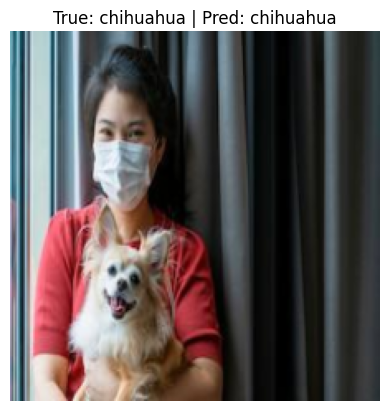

In [109]:
model.eval()

image: torch.Tensor
label: int
image, label = test_dataset[0]

image_input: torch.Tensor = image.unsqueeze(0).to(device)

with torch.no_grad():
    output: torch.Tensor = model(image_input)
    predicted: torch.Tensor
    _, predicted = torch.max(output, 1)

true_class: str = test_dataset.classes[label]
predicted_class: str = test_dataset.classes[predicted.item()]

print("True label:", true_class)
print("Predicted:", predicted_class)

title: str = f"True: {true_class} | Pred: {predicted_class}"

plt.imshow(image.permute(1, 2, 0).numpy())
plt.title(title)
plt.axis("off")
plt.show()

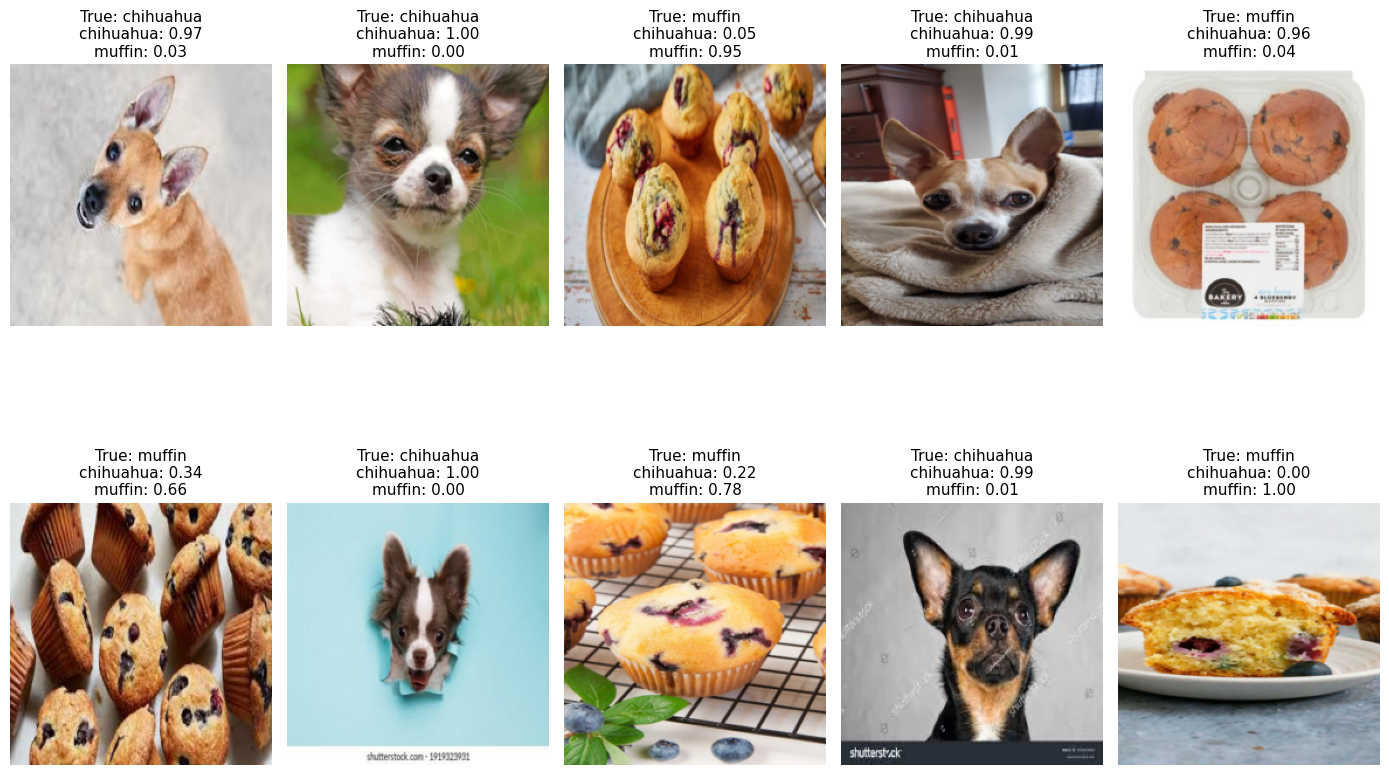

In [119]:
model.eval()

indices: list[int] = random.sample(range(len(test_dataset)), 10)

plt.figure(figsize=(14, 10))

i: int
idx: int
for i, idx in enumerate(indices):
    image: torch.Tensor
    label: int
    image, label = test_dataset[idx]

    input_tensor: torch.Tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output: torch.Tensor = model(input_tensor)
        probabilities: torch.Tensor = F.softmax(output, dim=1)[0]

    prob_text: str = "\n".join(
        f"{name}: {probabilities[j].item():.2f}"
        for j, name in enumerate(test_dataset.classes)
    )

    true_class: str = test_dataset.classes[label]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0).numpy())
    plt.title(f"True: {true_class}\n{prob_text}", fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.show()

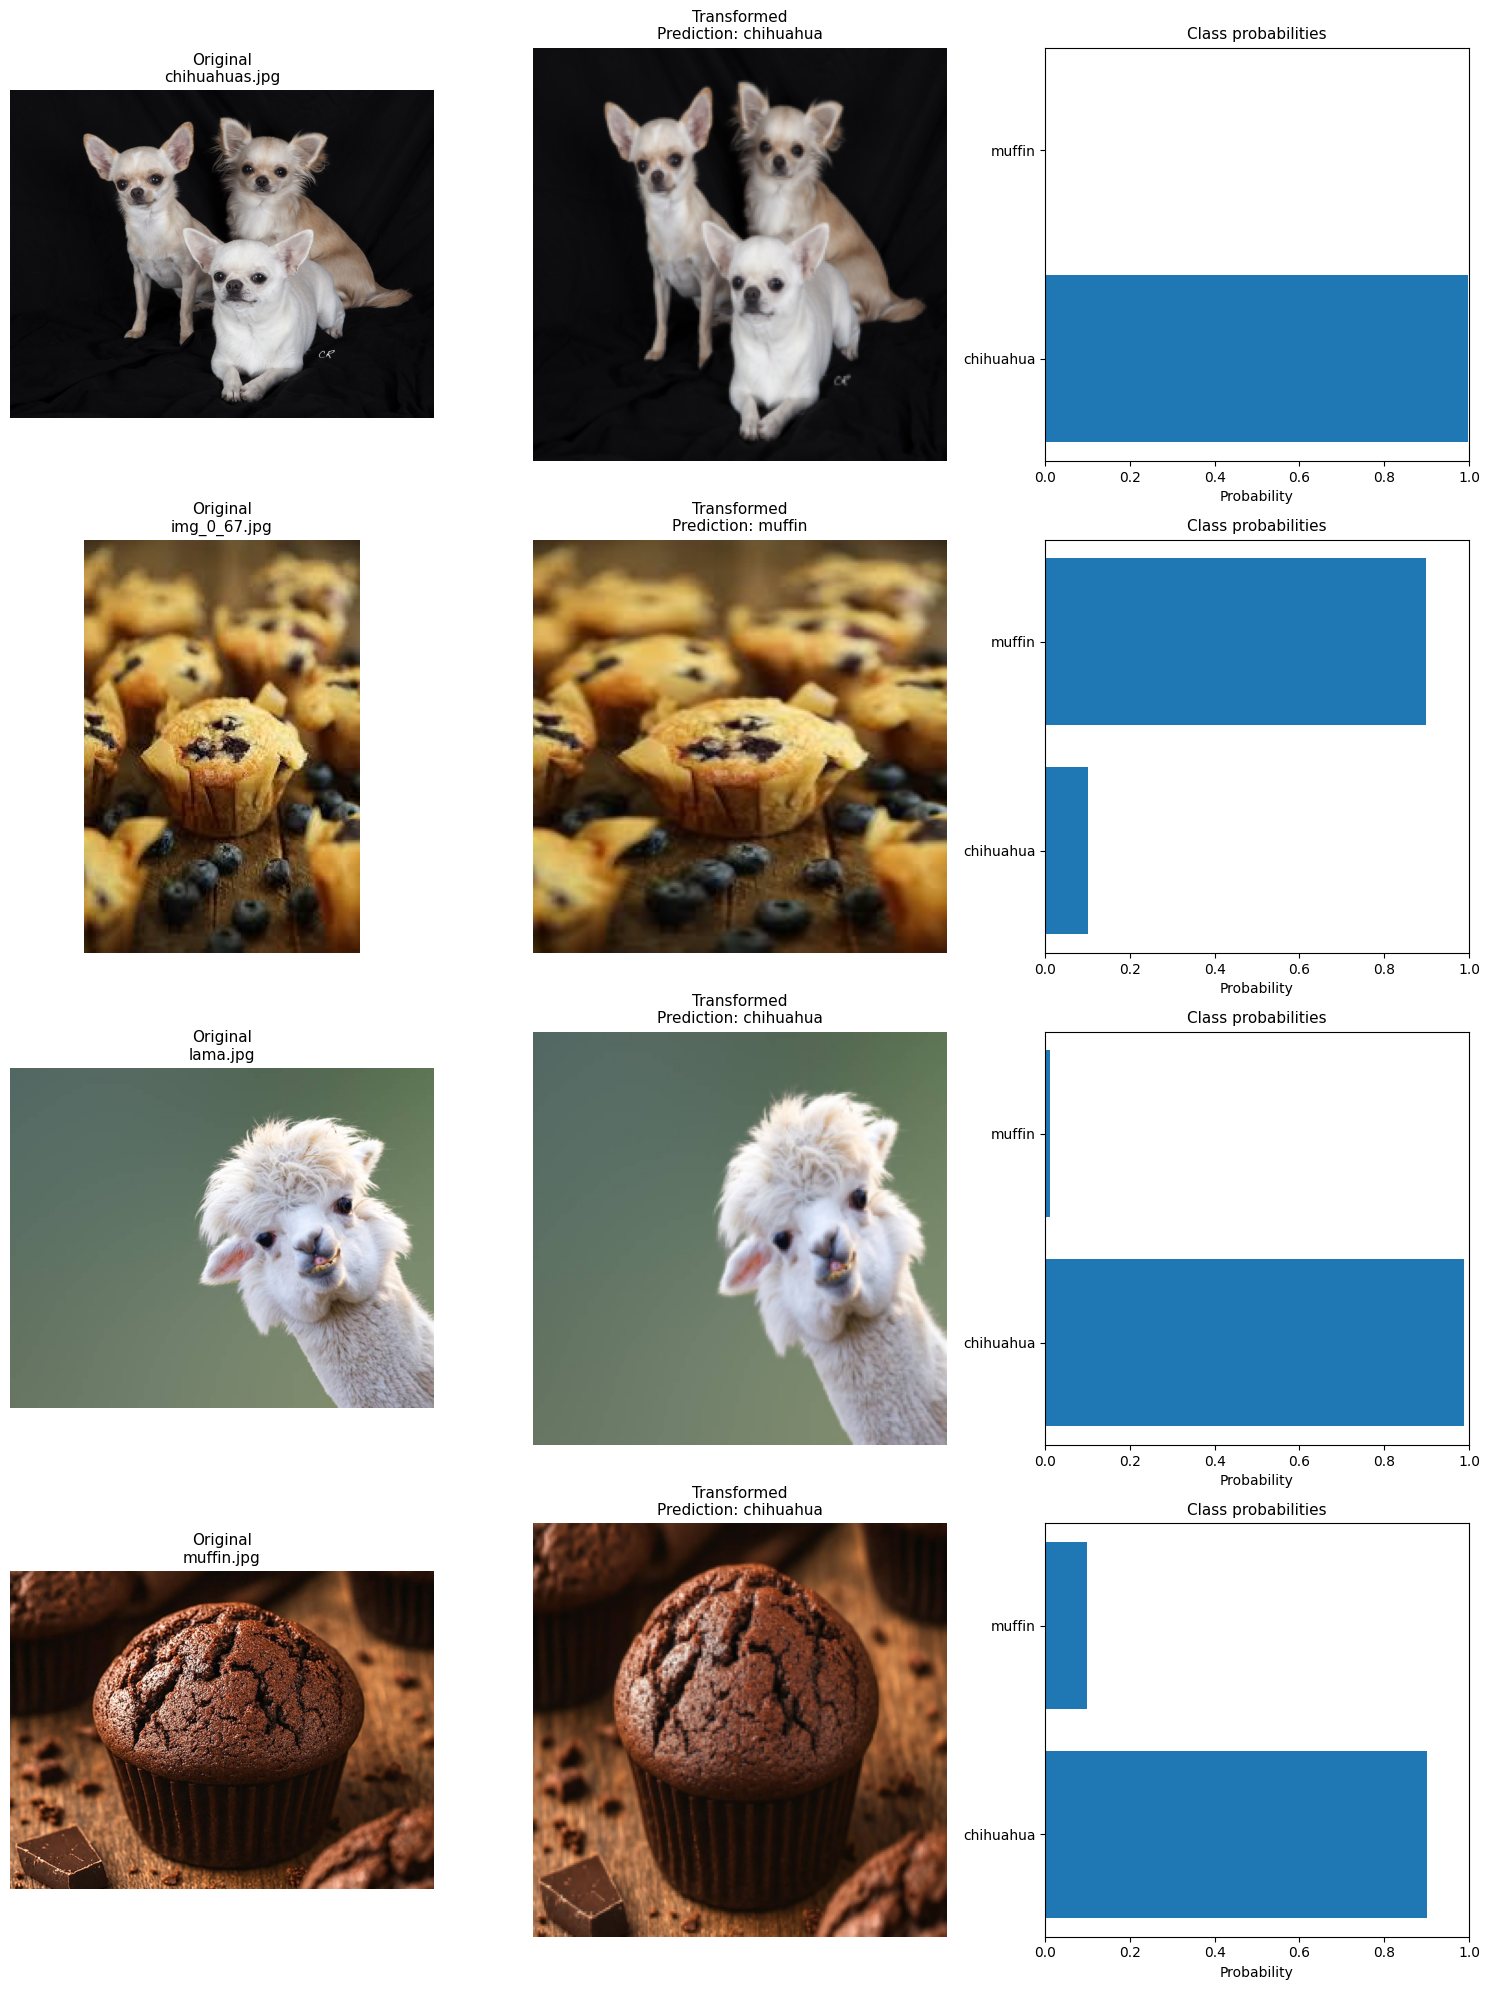

Total parameters: 12,850,530


In [118]:
import torch.nn.functional as F

img_paths: list[Path] = sorted(Path("./data/others").glob("*.jpg"))
img_paths: list[Path] = sorted(
    p for ext in ("*.jpg", "*.jpeg", "*.png")
    for p in Path("./data/others").glob(ext)
)

model.eval()

n_cols: int = 3
n_rows: int = len(img_paths)
plt.figure(figsize=(15, 5 * n_rows))

img_path: Path
for i, img_path in enumerate(img_paths):
    image: Image.Image = Image.open(img_path).convert("RGB")
    image_tensor: torch.Tensor = cast(torch.Tensor, transform(image))

    input_tensor: torch.Tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output: torch.Tensor = model(input_tensor)
        predicted: torch.Tensor
        _, predicted = torch.max(output, 1)
        probabilities: torch.Tensor = F.softmax(output, dim=1)

    class_name: str = test_dataset.classes[predicted.item()]

    probs: list[float] = [p.item() for p in probabilities[0]]

    # left: original image
    plt.subplot(n_rows, n_cols, i * n_cols + 1)
    plt.imshow(image)
    plt.title(f"Original\n{img_path.name}", fontsize=11)
    plt.axis("off")

    # middle: transformed image (denormalized for display)
    plt.subplot(n_rows, n_cols, i * n_cols + 2)
    plt.imshow(image_tensor.permute(1, 2, 0).numpy())
    plt.title(f"Transformed\nPrediction: {class_name}", fontsize=11)
    plt.axis("off")

    # right: probability bar chart
    plt.subplot(n_rows, n_cols, i * n_cols + 3)
    plt.barh(test_dataset.classes, probs)
    plt.xlim(0, 1)
    plt.xlabel("Probability")
    plt.title("Class probabilities", fontsize=11)

plt.tight_layout()
plt.show()

total_params: int = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Test precision

In [114]:
model.eval()

correct: int = 0
total: int = 0

with torch.no_grad():
    batch_images: torch.Tensor
    batch_labels: torch.Tensor
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        outputs: torch.Tensor = model(batch_images)

        predicted: torch.Tensor
        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += int((predicted == batch_labels).sum().item())

accuracy: float = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

total_params: int = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Test Accuracy: 0.8446
Total parameters: 12,850,530
